<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/hyperparam_optim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Optimization

### Setup


In [2]:
# INSTALLS, IMPORTS
import pandas as pd
import matplotlib.pyplot as plt

import torch  # for tensors
from torch import nn

!pip install torch_geometric  # for graphs
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

!pip install optuna  # for hyperparameter optimization
import optuna

!pip install kagglehub
import kagglehub

!pip install rdkit  # for molecule structures
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit.Chem import rdForceFieldHelpers
from rdkit.Chem import AllChem

!pip install py3Dmol  # for 3D molecule visualization
import py3Dmol


# DOWNLOAD DATA
data_path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", data_path)


# CONFIG
batch_size = 32

# hyperparameter optim
n_trials = 250
timeout = 60 * 60 * 6  # seconds
limit = 100  # epochs
patience = 10  # epochs without improvement

# final training
final_training_limit = 200  # epochs
final_training_patience = 13   # epochs without improvement

save_path = "/content"

SEED = 42
torch.manual_seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 49.1 MB/s eta 0:00:00


100%|██████████| 130k/130k [00:00<00:00, 55.6MB/s]

Extracting files...
Path to dataset: /root/.cache/kagglehub/datasets/markinsuff/lipophilicity/versions/1/Lipophilicity.csv


### Utility Functions

In [3]:
# UTIL

def graph_from_mol(mol):
  node_features = []
  edge_indices = []

  for atom in mol.GetAtoms():
    features = [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
    ]
    node_features.append(features)

  node_features = torch.tensor(node_features, dtype=torch.float)

  for bond in mol.GetBonds():
    start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    edge_indices.append([start, end])
    edge_indices.append([end, start])

  edge_indices = torch.tensor(edge_indices, dtype=torch.long)
  # transpose for torch_geometric
  edge_indices = edge_indices.t().contiguous()

  return Data(x=node_features, edge_index=edge_indices)


def mol_3d_from_mol(mol):
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  # optimize molecule geometry with Merck molecular force field (MMFF)
  AllChem.MMFFOptimizeMolecule(mol)

  mol_3d = Chem.MolToMolBlock(mol)
  return mol_3d


### Data

In [4]:
# DATA
class MoleculeDataset(Dataset):
  def __init__(self, csv_file):
    self.data = pd.read_csv(csv_file)
    self.normalize = False
    self.mean, self.std = self.data["exp"].mean(), self.data["exp"].std()

  def __len__(self):
    return len(self.data)

  def normalize_target(self, value: bool):
    self.normalize = value

  def __getitem__(self, i):
    smiles = self.data.loc[i, "RDKIT_SMILES"]
    mol = Chem.MolFromSmiles(smiles)
    graph = graph_from_mol(mol)

    exp = self.data.loc[i, "exp"]

    # target normalization
    if self.normalize:
      exp = (exp - self.mean) / self.std

    return graph, exp


dataset = MoleculeDataset(data_path)
dataset.normalize_target(True)

data_std = dataset.std

# split data
train_data, test_data = torch.utils.data.random_split(dataset, [0.85, 0.15],
  generator=torch.Generator().manual_seed(SEED))


### Model

In [5]:
# MODEL
class GraphNeuralNetwork(nn.Module):
  def __init__(self, n_conv_layers, hidden_dim, pool="mean", activation="relu", dropout_rate=0.3):
    super(GraphNeuralNetwork, self).__init__()

    self.conv_layers = nn.ModuleList()
    self.conv_layers.append(GCNConv(5, hidden_dim))

    self.batch_norm_layers = nn.ModuleList()
    self.batch_norm_layers.append(nn.BatchNorm1d(hidden_dim))

    for _ in range(n_conv_layers - 1):
      self.conv_layers.append(GCNConv(hidden_dim, hidden_dim))
      self.batch_norm_layers.append(nn.BatchNorm1d(hidden_dim))

    self.pool = {
      "mean": global_mean_pool,
      "max": global_max_pool,
    }[pool]

    self.activation = {
      "relu": nn.ReLU(),
      "leaky_relu": nn.LeakyReLU(),
      "prelu": nn.PReLU(),
      "elu": nn.ELU(),
    }[activation]

    self.linear = nn.Sequential(
      nn.Linear(hidden_dim, hidden_dim // 2),
      self.activation,
      nn.Dropout(dropout_rate),
      nn.Linear(hidden_dim // 2, 1),
    )

  def forward(self, x, edge_index, batch):
    for i in range(len(self.conv_layers)):
      x = self.conv_layers[i](x, edge_index)
      x = self.batch_norm_layers[i](x)
      x = self.activation(x)

    x = self.pool(x, batch)
    x = self.linear(x)
    return x

  def predict(self, mol):
    with torch.no_grad():
      graph = graph_from_mol(mol)
      if getattr(graph, 'batch', None) is None:
        graph.batch = torch.zeros(graph.x.shape[0], dtype=torch.long)
      output = self(graph.x, graph.edge_index, graph.batch)
      logd = output.item() * data_std + dataset.mean
      return logd

### Training and Testing

In [11]:
# TRAINING AND TESTING

def train(model, data_loader, loss_fn, optimizer, verbose=True):
  model.train()
  for i, (batch_data, target) in enumerate(data_loader):
    optimizer.zero_grad()
    output = model(batch_data.x, batch_data.edge_index, batch_data.batch)
    loss = loss_fn(output, target.unsqueeze(1))
    loss.backward()
    optimizer.step()

    if verbose and i % 10 == 0:
      loss_val = loss.item()
      current_samples = min((i + 1) * data_loader.batch_size, len(data_loader.dataset))
      print(f"loss: {loss_val:>7f}  [{current_samples:>5d}/{len(data_loader.dataset):>5d}]")

  print()

def evaluate(model, data_loader, loss_fn, dataset_name="", verbose=True):
  model.eval()
  total_loss = 0
  with torch.no_grad():
    for i, (batch_data, target) in enumerate(data_loader):
      output = model(batch_data.x, batch_data.edge_index, batch_data.batch)
      total_loss += loss_fn(output, target.unsqueeze(1)).item()

  avg_loss = total_loss / len(data_loader)

  if verbose:
    print(f"Average loss ({dataset_name}): {avg_loss:>8f}")
    rmse_logd = avg_loss**0.5 * data_std
    print(f"RMSE LogD ({dataset_name}): {rmse_logd:>8f}\n")

  return avg_loss

class EarlyStopping:
  def __init__(self, patience, save_best_model=True, model=None):
    if save_best_model:
      assert model is not None, "Model must be provided if save_best_model is True"

    self.patience = patience
    self.save_best_model = save_best_model
    self.model = model

    self.best_loss = float("inf")
    self.best_epoch = 0
    self.epochs_without_improvement = 0

  def should_stop(self, loss, epoch):
    if loss < self.best_loss:
      self.best_loss = loss
      self.best_epoch = epoch
      self.epochs_without_improvement = 0
      torch.save(self.model.state_dict(), "best_model_weights.pth")
    else:
      self.epochs_without_improvement += 1

    if self.epochs_without_improvement >= 1:
      print(f"Epochs without improvement: {self.epochs_without_improvement}")

      if self.epochs_without_improvement >= self.patience:
        print(f"Early stopping at epoch {epoch + 1}")
        print(f"Loading best model (Epoch {self.best_epoch + 1})\n")
        self.model.load_state_dict(torch.load("best_model_weights.pth"))
        return True

      print()
    return False



### Hyperparameter Optimization

In [ ]:
# HYPERPARAMETER OPTIMIZATION

def objective(trial):
  n_conv_layers = trial.suggest_int("n_conv_layers", 2, 4)
  hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
  pool = trial.suggest_categorical("pool", ["mean", "max"])
  activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "prelu"])
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])


  train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

  model = GraphNeuralNetwork(n_conv_layers, hidden_dim, pool, activation, dropout_rate)

  loss_fn = nn.MSELoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

  best_test_loss = float("inf")
  epochs_without_improvement = 0

  for epoch in range(limit):
    model.train()
    for batch_data, target in train_loader:
      optimizer.zero_grad()
      output = model(batch_data.x, batch_data.edge_index, batch_data.batch)
      loss = loss_fn(output, target.unsqueeze(1))
      loss.backward()
      optimizer.step()

    current_test_loss = evaluate(model, test_loader, loss_fn, verbose=False)
    lr_scheduler.step(current_test_loss)

    if current_test_loss < best_test_loss:
      best_test_loss = current_test_loss
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
      break

    trial.report(best_test_loss, epoch)

    # pruning
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()

  return best_test_loss

# Baysian hyperparameter optimization with Tree-structured Parzen Estimator
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner()

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print("  Loss ():", trial.value)
print("  RMSE logD:", trial.value**0.5 * data_std)

print("Best parameters:")
for key, value in trial.params.items():
  print(f"  {key}: {value}")

[I 2026-08-19 15:16:01,662] A new study created in memory with name: no-name-4533c4b5-faaa-423d-92d1-e302ec36a9a2


  0%|          | 0/120 [00:00<?, ?it/s]

[I 2026-08-19 15:25:17,316] Trial 0 finished with value: 0.9061508860439063 and parameters: {'n_conv_layers': 3, 'hidden_dim': 32, 'pool': 'mean', 'activation': 'leaky_relu', 'dropout_rate': 0.3832290311184182, 'learning_rate': 1.0994335574766187e-05, 'weight_decay': 0.0008706020878304854, 'batch_size': 16}. Best is trial 0 with value: 0.9061508860439063.
[I 2026-08-19 15:29:50,587] Trial 1 finished with value: 0.4970385983586311 and parameters: {'n_conv_layers': 2, 'hidden_dim': 64, 'pool': 'max', 'activation': 'prelu', 'dropout_rate': 0.28242799368681437, 'learning_rate': 0.00037183641805732076, 'weight_decay': 2.5081156860452307e-05, 'batch_size': 32}. Best is trial 1 with value: 0.4970385983586311.
[I 2026-08-19 15:39:16,018] Trial 2 finished with value: 0.5387014299631119 and parameters: {'n_conv_layers': 3, 'hidden_dim': 128, 'pool': 'mean', 'activation': 'prelu', 'dropout_rate': 0.27606099749584057, 'learning_rate': 1.7541893487450798e-05, 'weight_decay': 9.7803370166594e-05, 'b

### Final Training

Initial model performane
Average loss (train data): 0.991751
RMSE LogD (train data): 1.198032

Average loss (test data): 1.087304
RMSE LogD (test data): 1.254418

Epoch 1/200
loss: 0.975038  [   64/ 3570]
loss: 1.213796  [  704/ 3570]
loss: 0.803169  [ 1344/ 3570]
loss: 0.728673  [ 1984/ 3570]
loss: 0.872169  [ 2624/ 3570]
loss: 0.629296  [ 3264/ 3570]

Evaluating
Average loss (train data): 0.810469
RMSE LogD (train data): 1.083017

Average loss (test data): 0.886312
RMSE LogD (test data): 1.132557

Epoch 2/200
loss: 0.969186  [   64/ 3570]
loss: 0.919427  [  704/ 3570]
loss: 0.685273  [ 1344/ 3570]
loss: 0.603032  [ 1984/ 3570]
loss: 0.752331  [ 2624/ 3570]
loss: 0.606587  [ 3264/ 3570]

Evaluating
Average loss (train data): 0.680844
RMSE LogD (train data): 0.992638

Average loss (test data): 0.734624
RMSE LogD (test data): 1.031097

Epoch 3/200
loss: 0.886059  [   64/ 3570]
loss: 0.593384  [  704/ 3570]
loss: 0.799345  [ 1344/ 3570]
loss: 0.718910  [ 1984/ 3570]
loss: 0.609333  [ 262

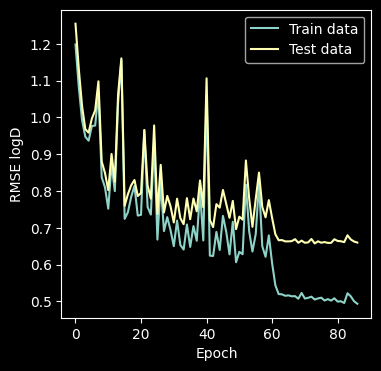


Model saved


In [12]:
# FINAL TRAINING

model = GraphNeuralNetwork(
    n_conv_layers=trial.params["n_conv_layers"],
    hidden_dim=trial.params["hidden_dim"],
    pool=trial.params["pool"],
    activation=trial.params["activation"],
    dropout_rate=trial.params["dropout_rate"],
)

train_loader = DataLoader(train_data, batch_size=trial.params["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=trial.params["batch_size"], shuffle=False)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=trial.params["learning_rate"],
    weight_decay=trial.params["weight_decay"],
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

def train_model(
    model,
    train_loader,
    test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    patience=final_training_patience,
    limit=final_training_limit,
    plot=True,
    save=True,
):
  train_losses = []
  test_losses = []

  early_stopping = EarlyStopping(patience, save_best_model=True, model=model)

  print("Initial model performane")
  train_loss = evaluate(model, train_loader, loss_fn, dataset_name="train data")
  train_losses.append(train_loss)
  test_loss = evaluate(model, test_loader, loss_fn, dataset_name="test data")
  test_losses.append(test_loss)

  for epoch in range(limit):
    print(f"Epoch {epoch + 1}/{limit}")
    train(model, train_loader, loss_fn, optimizer)

    print("Evaluating")
    train_loss = evaluate(model, train_loader, loss_fn, dataset_name="train data")
    train_losses.append(train_loss)
    test_loss = evaluate(model, test_loader, loss_fn, dataset_name="test data")
    test_losses.append(test_loss)

    lr_scheduler.step(test_loss)

    if early_stopping.should_stop(test_loss, epoch):
      break

  print("Training and testing completed")

  # total parameters
  total_params = sum(param.numel() for param in model.parameters())
  print(f"Total parameters: {total_params:,}")

  # RMSE logD
  best_test_loss = min(test_losses)
  best_rmse_logd = best_test_loss**0.5 * data_std
  print(f"RMSE logD (test data): {best_rmse_logd:>8f}")
  print()

  # plot
  if plot:
    train_rmse = [loss**0.5 * data_std for loss in train_losses]
    test_rmse = [loss**0.5 * data_std for loss in test_losses]

    plt.style.use('dark_background')
    plt.figure(figsize=(4, 4))
    plt.plot(train_rmse, label="Train data")
    plt.plot(test_rmse, label="Test data")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE logD")
    plt.legend()

    plt.show()
    print()

  # save
  if save:
    torch.save(model, save_path+"/model.pth")
    torch.save(model.state_dict(), save_path+"/model_weights.pth")
    print("Model saved")


train_model(model, train_loader, test_loader)


### Molecule Visuzation and Example Prediction

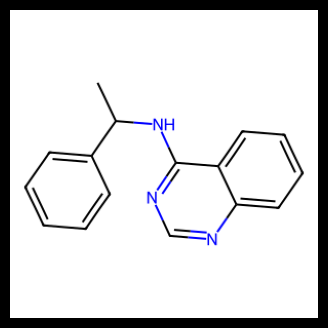

C16H15N3
Predicted logD: 3.34
True logD: 3.40
Error: 0.06


In [19]:
# EXAMPLE
visualization = "2d"

i = torch.randint(0, len(test_data), (1,)).item()
mol = Chem.MolFromSmiles(test_data.dataset.data.loc[i, "RDKIT_SMILES"])
formula = rdMolDescriptors.CalcMolFormula(mol)
exp = test_data.dataset.data.loc[i, "exp"]

model.eval()
pred = model.predict(mol)
error = abs(pred - exp)

if visualization not in ["2d", "3d", "none"]:
  raise ValueError("Visualization must be either '2d', '3d' or 'none'")

match visualization:

  case "2d":
    plt.figure(figsize=(4,4))
    plt.axis("off")
    image = Draw.MolToImage(mol)
    plt.imshow(image)
    plt.show()

  case "3d":
    view = py3Dmol.view(width=400, height=400)
    view.setBackgroundColor('black')
    view.addModel(mol_3d_from_mol(mol), "mol")
    view.setStyle({
        "stick": {},
        "sphere": {"scale": 0.3}
        })
    view.zoomTo()
    view.show()

  case "none":
    pass

print(formula)
print(f"Predicted logD: {pred:.2f}")
print(f"True logD: {exp:.2f}")
print(f"Error: {error:.2f}")